# Lesson 7: Introduction to Design

Lessons 1-6 all started from a **given sequence** and asked questions about
its structure, probabilities, defect, and tube behavior. This notebook turns
the problem around: start from a **target structure**, and let NUPACK search
for a *sequence* that achieves it - using exactly the ensemble defect from
lesson 4 as the quantity being minimized.

**By the end of this notebook you will be able to:**

- Build a design problem from `Domain` (sequence with wildcards),
  `TargetStrand`, `TargetComplex` (strands + target structure), and
  `TargetTube`.
- Run `tube_design(...).run(trials=N)` and read off each trial's
  `ensemble_defect` and resolved domain sequences.
- **Close the loop**: feed a designed sequence back into
  `complex_analysis`/`tube_analysis` (lessons 1-5) and verify it folds as
  intended.
- Confirm that the design algorithm's reported defect is the *same* quantity
  computed by `defect(...)` in lesson 4.

**Prerequisites:** [`01_introduction.ipynb`](01_introduction.ipynb) (MFE,
pair probabilities), [`04_defect_analysis.ipynb`](04_defect_analysis.ipynb)
(ensemble defect), [`05_basic_tube_analysis.ipynb`](05_basic_tube_analysis.ipynb)
(`Tube`, yield).


## Introduction

Every analysis lesson so far answered some version of "given this sequence,
what does it do?" Design answers the inverse question: "I want a molecule
that does *this* - what sequence should I synthesize?"

NUPACK's design module expresses this with a small hierarchy of objects:

- **`Domain`**: a stretch of sequence, possibly with wildcards. `Domain("N13",
  name="d")` means "13 nucleotides, each free to be any of A/C/G/U" - the
  search space.
- **`TargetStrand`**: one or more domains concatenated into a strand.
- **`TargetComplex`**: one or more target strands, plus (optionally) a target
  **secondary structure** in dot-parens(-plus) notation - exactly the
  notation from lessons 1-2.
- **`TargetTube`**: one or more target complexes at specified concentrations
  - exactly the `Tube` from lesson 5, but with designable strands.

`tube_design(tubes=[...], model=...)` then builds an optimizer; calling
`.run(trials=N)` runs the stochastic search $N$ times (each trial starting
from a different random sequence) and returns $N$ `Result` objects, each with
an `ensemble_defect` and a `domains` mapping from `Domain` to its resolved
sequence.

### Roadmap

1. Design a sequence for the lesson-1 hairpin's target structure
   (`(((((...)))))`), run several trials, and compare their defects.
2. Take the best trial's sequence and **re-analyze it** with
   `complex_analysis` (lesson 1) - confirm the MFE matches the target and that
   `defect(...)` (lesson 4) reproduces the design's own reported number.
3. Design a two-strand duplex (`TargetComplex` with two `TargetStrand`s) and
   close the loop with `tube_analysis` (lesson 5) to check its yield.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import forgi.graph.bulge_graph as fgb
import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


def find_conc(conc_dict, *strands):
    '''Look up the equilibrium concentration of the complex containing exactly these strands.'''
    names = sorted(s.name for s in strands)
    for cx, val in conc_dict.items():
        if sorted(s.name for s in cx.strands) == names:
            return val
    return 0.0


def per_nt_defect(structure, pairs_matrix):
    '''Per-nucleotide defect d_i = 1 - P[i, partner(i)] (or 1 - P[i, i] if unpaired).'''
    n = len(structure)
    stack = []
    partner = [-1] * n
    for i, ch in enumerate(structure):
        if ch == "(":
            stack.append(i)
        elif ch == ")":
            j = stack.pop()
            partner[i] = j
            partner[j] = i
    d = np.empty(n)
    for i in range(n):
        if partner[i] == -1:
            d[i] = 1 - pairs_matrix[i, i]
        else:
            d[i] = 1 - pairs_matrix[i, partner[i]]
    return d


def plot_structure(sequence, structure, ax, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq=sequence)
    fvm.plot_rna(bg, ax=ax, lighten=0.7, text_kwargs={"fontweight": "black"})
    ax.set_title(title)


## Theory: design as defect minimization

`tube_design` searches over sequences (subject to whatever wildcards/domains
you specify) to minimize a **weighted ensemble defect** across all the
`TargetComplex`es in all the `TargetTube`s - exactly the per-complex
normalized defect from lesson 4, $\mathrm{defect}(s^*) = \frac{1}{N}\sum_i
d_i$, generalized to a weighted sum over multiple complexes/tubes when there
is more than one.

Each call to `.run(trials=N)` performs $N$ independent stochastic searches
(local optimization from $N$ different random starting sequences) and returns
$N$ `Result` objects. Because the search is stochastic, **different trials
can land on different sequences with different final defects** - there is no
guarantee any trial reaches defect 0, and for some target structures defect 0
may not even be achievable (just as lesson 4 showed that "end fraying" puts a
floor under the hairpin's defect regardless of sequence).

A `Result` exposes:

- `result.ensemble_defect`: the final (normalized) defect - the same quantity
  `defect(...)` computes in lesson 4.
- `result.domains`: a mapping from each `Domain` object to its resolved
  sequence (a plain string via `str(...)`).


## Worked example 1: designing a sequence for the lesson-1 hairpin

The lesson-1 hairpin had target structure `(((((...)))))` (13 nt: a 5-bp stem
and a 3-nt loop). Instead of starting from `seq = "CGCGCUUUGCGCG"`, we ask
NUPACK to find *any* 13-nt sequence that folds into this structure with low
defect.


In [2]:
target_structure = "(((((...)))))"

d_hp = Domain("N13", name="d_hp")
hp_strand = TargetStrand([d_hp], name="hp_strand")
hp_complex = TargetComplex([hp_strand], target_structure, name="hp_complex")
hp_tube = TargetTube(on_targets={hp_complex: 1e-6}, name="hp_tube")

hp_design = tube_design(tubes=[hp_tube], model=model)
hp_results = hp_design.run(trials=5)

hp_table = pd.DataFrame(
    {
        "trial": range(len(hp_results)),
        "sequence": [str(r.domains[d_hp]) for r in hp_results],
        "ensemble defect": [r.ensemble_defect for r in hp_results],
    }
)
display(hp_table)


,trial,sequence,ensemble defect
0,0,GGCGGGCCCCGCC,0.012853
1,1,GCCCCGUCGGGGC,0.013949
2,2,GCUUCUGGGAAGC,0.014995
3,3,GGAUGGCACAUCC,0.017140
4,4,GGACCUCCGGUCC,0.010262


## Visualization: defect across trials


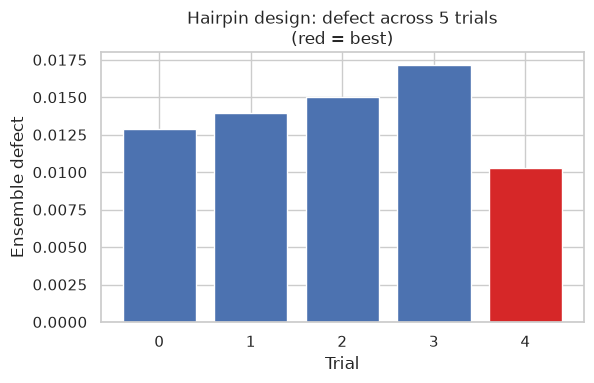

Best trial: 4, sequence: GGACCUCCGGUCC, defect: 0.01026


In [3]:
best_idx = hp_table["ensemble defect"].idxmin()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#d62728" if i == best_idx else "#4c72b0" for i in hp_table["trial"]]
ax.bar(hp_table["trial"], hp_table["ensemble defect"], color=colors)
ax.set_xlabel("Trial")
ax.set_ylabel("Ensemble defect")
ax.set_title(f"Hairpin design: defect across {len(hp_results)} trials\n(red = best)")
ax.set_xticks(hp_table["trial"])
fig.tight_layout()
plt.show()

best_seq = hp_table.loc[best_idx, "sequence"]
print(f"Best trial: {best_idx}, sequence: {best_seq}, defect: {hp_table.loc[best_idx, 'ensemble defect']:.5f}")


**Interpretation.** All trials land on different sequences (the search starts
from different random points), and all reach low defect - but not
necessarily the *same* defect. Every trial is a valid, independently-found
solution to "a 13-nt sequence that folds into `(((((...)))))`"; there is no
single "correct" answer, only better or worse ones by defect.


## Closing the loop: re-analyze the designed sequence

Take the best trial's sequence and run it through `complex_analysis`, exactly
as in lesson 1 - does it actually fold into the target structure?


In [4]:
best_strand = Strand(best_seq, name="designed")
best_complex = Complex([best_strand], name="designed_complex")
best_result = complex_analysis(complexes=[best_complex], model=model, compute=["pfunc", "mfe", "pairs"])[best_complex]

mfe_structure = str(best_result.mfe[0].structure)
print(f"target structure: {target_structure}")
print(f"MFE structure:    {mfe_structure}")
print(f"match: {mfe_structure == target_structure}")


target structure: (((((...)))))
MFE structure:    (((((...)))))
match: True


findfont: Failed to find font weight black, now using 700.


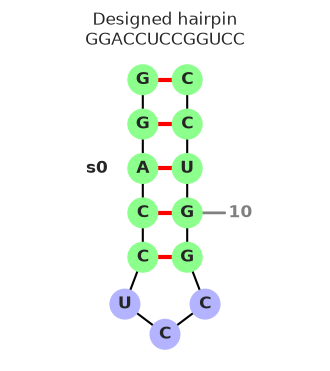

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_structure(best_seq, mfe_structure, ax, f"Designed hairpin\n{best_seq}")
plt.show()


Now reproduce the design's reported defect using `defect(...)` from lesson 4,
and look at the per-nucleotide defect profile.


design's ensemble_defect: 0.010262
defect(...) recomputed:   0.010262


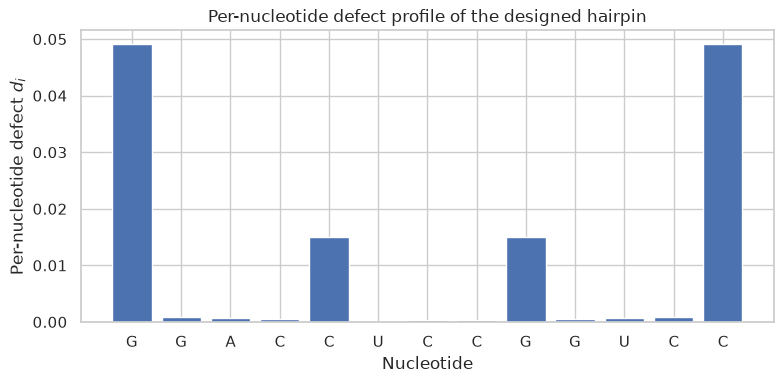

In [6]:
defect_recomputed = defect(target_structure, [best_seq], model=model)
print(f"design's ensemble_defect: {hp_table.loc[best_idx, 'ensemble defect']:.6f}")
print(f"defect(...) recomputed:   {defect_recomputed:.6f}")

p_best = best_result.pairs.to_array()
d_best = per_nt_defect(target_structure, p_best)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if di > 0.05 else "#4c72b0" for di in d_best]
ax.bar(range(len(best_seq)), d_best, color=colors)
ax.set_xticks(range(len(best_seq)))
ax.set_xticklabels(list(best_seq))
ax.set_xlabel("Nucleotide")
ax.set_ylabel("Per-nucleotide defect $d_i$")
ax.set_title("Per-nucleotide defect profile of the designed hairpin")
fig.tight_layout()
plt.show()


**Interpretation.** The MFE of the designed sequence matches the target
structure exactly, and `defect(...)` reproduces the design's own
`ensemble_defect` to within floating-point precision - **the design algorithm
is literally minimizing the same quantity from lesson 4**. The per-nucleotide
profile typically still shows the terminal pair as the largest contributor
(end fraying, lesson 1/4) - design reduces defect, but a hairpin's terminal
pair fraying is a feature of *any* sequence with this loop size, not a flaw
that more optimization would remove.


## Worked example 2: designing a two-strand duplex

Now design two complementary strands from scratch, targeting the fully-paired
9-bp duplex structure from lesson 2 (`(((((((((+)))))))))`). Each strand gets
its own `Domain`/`TargetStrand`; both appear together in one `TargetComplex`
with the target structure.


In [7]:
duplex_structure = "(((((((((+)))))))))"

d_a = Domain("N9", name="d_a")
d_b = Domain("N9", name="d_b")
strand_a = TargetStrand([d_a], name="strand_a")
strand_b = TargetStrand([d_b], name="strand_b")
duplex_complex = TargetComplex([strand_a, strand_b], duplex_structure, name="duplex_complex")
duplex_tube = TargetTube(on_targets={duplex_complex: 1e-6}, name="duplex_tube")

duplex_design = tube_design(tubes=[duplex_tube], model=model)
duplex_results = duplex_design.run(trials=3)

duplex_table = pd.DataFrame(
    {
        "trial": range(len(duplex_results)),
        "sequence a": [str(r.domains[d_a]) for r in duplex_results],
        "sequence b": [str(r.domains[d_b]) for r in duplex_results],
        "ensemble defect": [r.ensemble_defect for r in duplex_results],
    }
)
display(duplex_table)


,trial,sequence a,sequence b,ensemble defect
0,0,GCGGUCUGC,GUAGACCGC,0.019986
1,1,GGGUUCCGC,GCGGAACCC,0.011763
2,2,GCGAUACCC,GGGUAUCGC,0.014649


Take the best trial and close the loop with `tube_analysis` (lesson 5): mix
the two designed strands at 1 $\mu$M each and check the duplex yield.


In [8]:
best_duplex_idx = duplex_table["ensemble defect"].idxmin()
seq_a = duplex_table.loc[best_duplex_idx, "sequence a"]
seq_b = duplex_table.loc[best_duplex_idx, "sequence b"]

strand_a_designed = Strand(seq_a, name="a")
strand_b_designed = Strand(seq_b, name="b")

duplex_check_tube = Tube(
    strands={strand_a_designed: 1e-6, strand_b_designed: 1e-6},
    complexes=SetSpec(max_size=2),
    name="check",
)
check_result = tube_analysis(tubes=[duplex_check_tube], model=model, compute=["pfunc", "mfe"])
conc = check_result[duplex_check_tube].complex_concentrations
ab = Complex([strand_a_designed, strand_b_designed], name="ab")

yield_ab = find_conc(conc, strand_a_designed, strand_b_designed) / 1e-6
mfe_ab = str(check_result[ab].mfe[0].structure)

print(f"sequence a: {seq_a}")
print(f"sequence b: {seq_b}")
print(f"MFE of (a+b): {mfe_ab}")
print(f"target:       {duplex_structure}")
print(f"yield of (a+b) at 1 uM each: {yield_ab:.4f}")


sequence a: GGGUUCCGC
sequence b: GCGGAACCC
MFE of (a+b): (((((((((+)))))))))
target:       (((((((((+)))))))))
yield of (a+b) at 1 uM each: 0.9988


**Interpretation.** The designed pair forms the target duplex as its MFE, and
the yield at 1 $\mu$M is close to 1 - typically higher than the
"hand-picked" `a`/`b` pair from lesson 2/5 (yield $\approx 0.96$), because the
design algorithm explicitly searched for sequences with *low defect for this
exact structure*, rather than just being *a* complementary pair.


## Best practices and common pitfalls

- **Run multiple trials.** The search is stochastic; one trial might land on
  a noticeably worse local optimum than another. `trials=5` or more, picking
  the minimum-defect result, is standard practice - lesson 9 will also show
  how to weight defect across *multiple* complexes/tubes at once.
- **Always close the loop.** A low `ensemble_defect` from the design module
  is a strong signal, but re-running `complex_analysis`/`tube_analysis` on
  the literal output sequence (as done above) is the same kind of
  "trust but verify" check you'd want before ordering oligos.
- **Domain length determines the search space size, not the answer.**
  `Domain("N13")` searches over all $4^{13}$ possible 13-mers (in practice,
  via local search, not exhaustively) - longer domains and more
  strands/complexes make each `tube_design` call slower.
- **A target structure that's hard to achieve will show up as a defect floor
  across all trials**, not just one bad trial - if every trial in
  `hp_table`/`duplex_table` has similarly mediocre defect, that's a signal
  about the *target structure* (e.g. lesson 4's "everywhere uncertain" stem
  pattern), not the optimizer.


## Summary

In this notebook you:

1. Built design problems with `Domain` -> `TargetStrand` -> `TargetComplex`
   (+ target structure) -> `TargetTube`.
2. Ran `tube_design(...).run(trials=N)`, compared `ensemble_defect` across
   trials, and picked the best.
3. **Closed the loop**: re-analyzed designed sequences with
   `complex_analysis`/`tube_analysis` from lessons 1-5, confirming the MFE
   matches the target and that `defect(...)` (lesson 4) reproduces the
   design's own reported defect exactly.

**Next:** [`08_design_constraints.ipynb`](08_design_constraints.ipynb) adds
**constraints** to the search - fixing specific bases, using IUPAC wildcard
alphabets beyond plain `N`, and requiring complementarity between domains.


## Exercises

1. Increase `trials` to 10 for the hairpin design. Does the best defect
   improve noticeably over 5 trials, or does it plateau?
2. Design a sequence for the `seq2`-style target structure from lesson 2
   (`(((...(((...)))...)))`, 21 nt, two nested hairpins). Compare its defect
   to the 0.16 defect that the *hand-picked* `seq2` had in lesson 4 - is the
   designed sequence better?
